In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

import warnings
import matplotlib as mpl

In [2]:
# 1) Сброс всех старых настроек (важно, если ранее был dark_background)
mpl.rcParams.update(mpl.rcParamsDefault)

In [3]:
# 2) Белый стиль
plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
# 3) Глобальные настройки красоты
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "grid.color": "#E0E0E0",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

In [5]:
# 4) При желании: приглушаем FutureWarning от statsmodels/causalimpact
warnings.filterwarnings(
    "ignore",
    message=r"Unknown keyword arguments: dict_keys\(\['alpha'\]\)",
    category=FutureWarning,
)

In [6]:
def beautify_causalimpact_plot(title: str, suptitle_y: float = 1.02):
    """
    Делает график CausalImpact на белом фоне + понятные цвета.
    Вызывай сразу после bsts.result.plot()
    """
    fig = plt.gcf()
    fig.set_facecolor("white")

    axes = fig.axes
    for ax in axes:
        ax.set_facecolor("white")
        ax.grid(True, alpha=0.7)
        ax.tick_params(axis="x", rotation=0)

    # Попробуем перекрасить линии по осям (работает стабильно, т.к. структура 3 subplot)
    # 0: Observation vs prediction
    if len(axes) >= 1:
        ax0 = axes[0]
        lines = ax0.get_lines()
        # обычно там 2 линии: model (pred) и endog (actual)
        for ln in lines:
            lab = (ln.get_label() or "").lower()
            if "model" in lab or "pred" in lab:
                ln.set_color("#1f77b4")   # синий
                ln.set_linewidth(2.0)
                ln.set_linestyle("--")
            elif "endog" in lab or "actual" in lab or "response" in lab:
                ln.set_color("#111111")   # почти черный
                ln.set_linewidth(2.0)

        # доверительный интервал (заливка) — collections[0] обычно PolyCollection
        for coll in ax0.collections:
            coll.set_alpha(0.18)
            coll.set_facecolor("#1f77b4")

        ax0.set_title("Observed vs predicted")

    # 1: Difference
    if len(axes) >= 2:
        ax1 = axes[1]
        for ln in ax1.get_lines():
            ln.set_color("#ff7f0e")  # оранжевый для эффекта
            ln.set_linewidth(2.0)
        for coll in ax1.collections:
            coll.set_alpha(0.18)
            coll.set_facecolor("#ff7f0e")
        ax1.set_title("Pointwise effect")

    # 2: Cumulative impact
    if len(axes) >= 3:
        ax2 = axes[2]
        for ln in ax2.get_lines():
            ln.set_color("#ff7f0e")
            ln.set_linewidth(2.2)
        for coll in ax2.collections:
            coll.set_alpha(0.18)
            coll.set_facecolor("#ff7f0e")
        ax2.set_title("Cumulative effect")

    fig.suptitle(title, y=suptitle_y)
    fig.tight_layout()
    return fig

In [7]:
# Подключаем наши модели
sys.path.append(os.path.abspath('..'))
from src.models import CausalImpactBSTS

In [8]:
# ==========================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ OLIST
# ==========================================
print("Загрузка данных...")
orders = pd.read_csv('../data/olist_orders_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')

Загрузка данных...


In [9]:
# Мержим таблицы
df = orders.merge(payments, on='order_id').merge(customers, on='customer_id')

In [10]:
# Переводим время покупки в формат даты
df['date'] = pd.to_datetime(df['order_purchase_timestamp']).dt.date

In [11]:
# Агрегируем выручку (GMV) по дням и штатам
daily_gmv = df.groupby(['date', 'customer_state'])['payment_value'].sum().reset_index()

In [12]:
# Выбираем спокойный период (весна 2018) и берем 5 крупных штатов, чтобы ряды были стабильными
states_to_keep = ['RJ', 'MG', 'RS', 'PR', 'SC'] # RJ будет тестовым, остальные - контроль
daily_gmv = daily_gmv[daily_gmv['customer_state'].isin(states_to_keep)]
daily_gmv = daily_gmv[(daily_gmv['date'] >= pd.to_datetime('2018-02-01').date()) &
                      (daily_gmv['date'] <= pd.to_datetime('2018-06-30').date())]

In [13]:
# Переименовываем колонки под формат нашей модели
panel = daily_gmv.rename(columns={'date': 'time', 'customer_state': 'unit', 'payment_value': 'metric'})

In [14]:
# RJ (Рио-де-Жанейро) - тестовый штат
panel['is_test'] = np.where(panel['unit'] == 'RJ', 1, 0)

In [15]:
# Определяем дату "вмешательства" (например, 1 мая 2018)
dates = sorted(panel['time'].unique())
treatment_date = pd.to_datetime('2018-05-01').date()
t_pre = dates.index(treatment_date) # Узнаем индекс дня вмешательства
panel['post_treatment'] = np.where(panel['time'] >= treatment_date, 1, 0)

print(f"Данные готовы. Дней до вмешательства: {t_pre}, Дней после: {len(dates) - t_pre}")

Данные готовы. Дней до вмешательства: 89, Дней после: 61


In [16]:
# ==========================================
# 2. ЭКСПЕРИМЕНТ 1: A/A ТЕСТ (ПЛАЦЕБО)
# ==========================================
print("\n=== ЗАПУСК A/A ТЕСТА (Истинный эффект = 0) ===")
# В этот период ничего не происходило. Алгоритм должен показать эффект ~ 0
bsts_aa = CausalImpactBSTS(t_pre=t_pre)
effect_aa, lower_aa, upper_aa = bsts_aa.fit_predict(panel)


=== ЗАПУСК A/A ТЕСТА (Истинный эффект = 0) ===


In [17]:
print(f"Оценка эффекта (A/A): {effect_aa:.2f}")
print(f"Доверительный интервал: [{lower_aa:.2f}, {upper_aa:.2f}]")
# Если 0 находится внутри интервала - тест пройден!

Оценка эффекта (A/A): -218.16
Доверительный интервал: [4341.24, -4777.55]


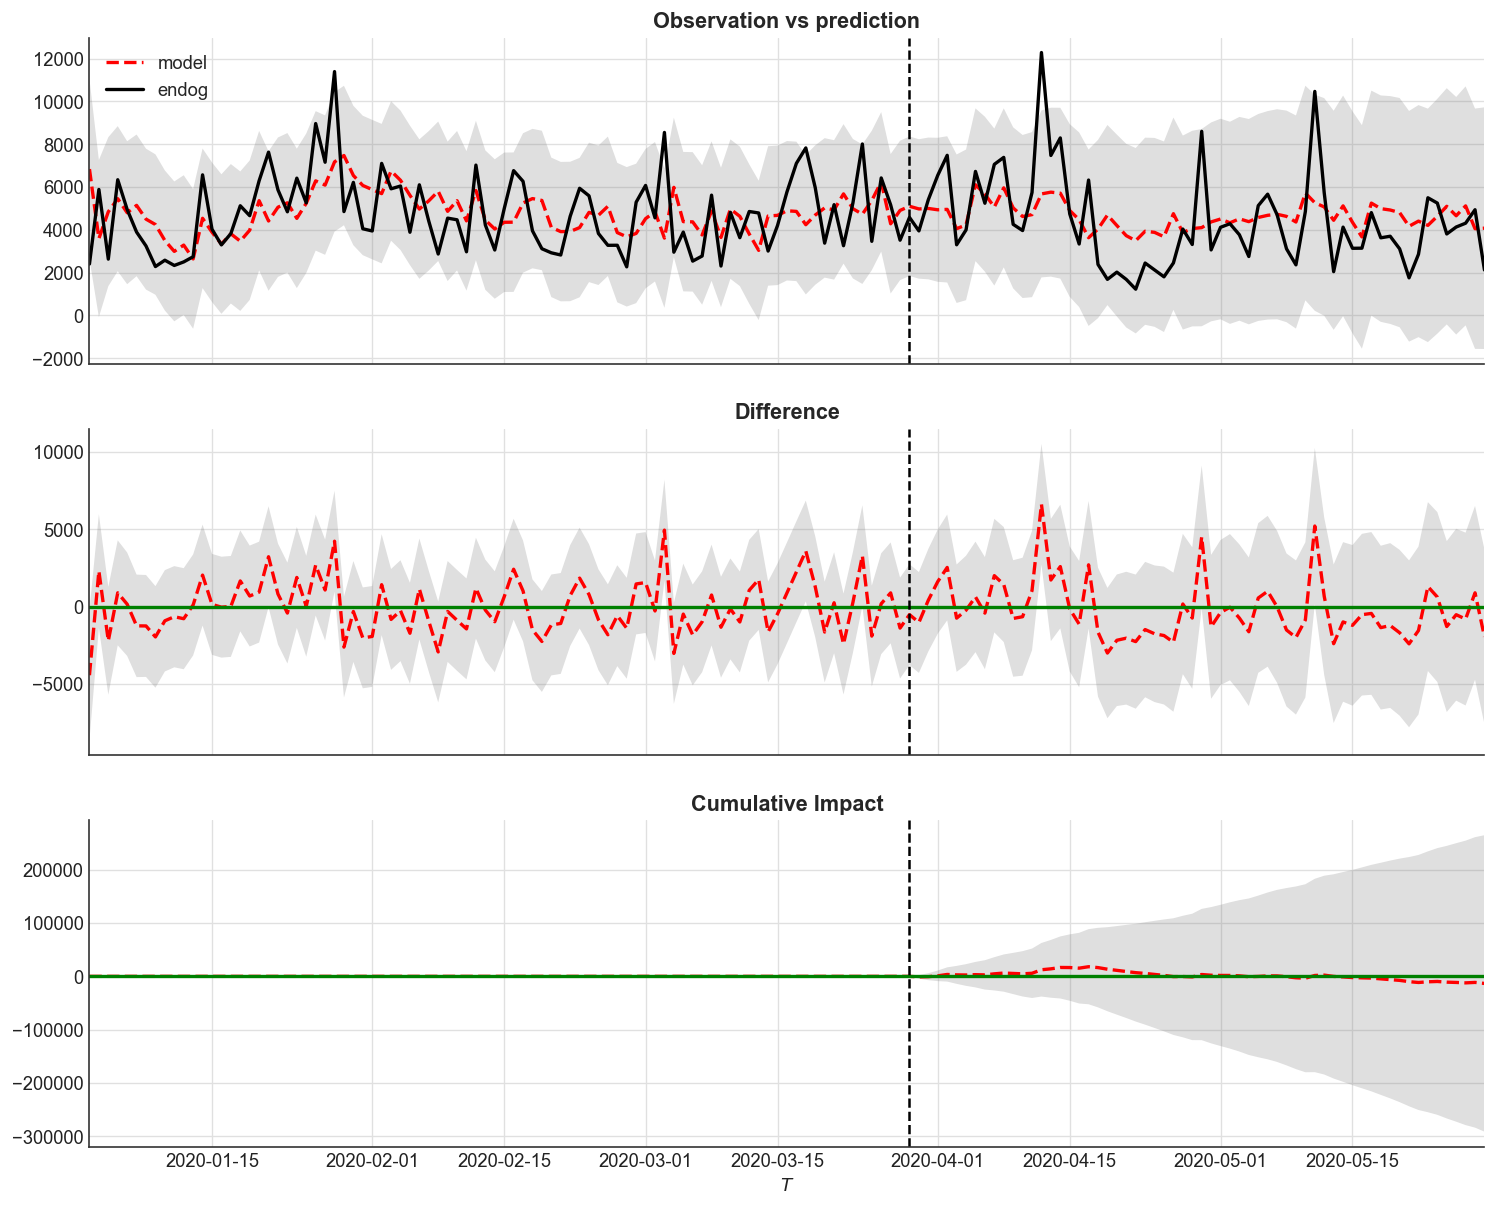

<Figure size 768x576 with 0 Axes>

In [18]:
# Рисуем и сохраняем график
bsts_aa.result.plot()
beautify_causalimpact_plot("A/A Test (Placebo) on Olist Data")
plt.show()

In [19]:
# ==========================================
# 3. ЭКСПЕРИМЕНТ 2: ИНЪЕКЦИЯ ЭФФЕКТА (+20%)
# ==========================================
print("\n=== ЗАПУСК ТЕСТА С ИНЪЕКЦИЕЙ (+20% к выручке) ===")
panel_inj = panel.copy()


=== ЗАПУСК ТЕСТА С ИНЪЕКЦИЕЙ (+20% к выручке) ===


In [20]:
# Находим среднюю выручку RJ до вмешательства, чтобы понимать масштаб
avg_gmv_rj_pre = panel[(panel['is_test'] == 1) & (panel['post_treatment'] == 0)]['metric'].mean()
expected_effect_abs = avg_gmv_rj_pre * 0.20 # Ожидаемый абсолютный эффект (20% от базы)

In [21]:
# Увеличиваем выручку RJ на 20% после 1 мая
mask = (panel_inj['is_test'] == 1) & (panel_inj['post_treatment'] == 1)
panel_inj.loc[mask, 'metric'] *= 1.20

In [22]:
bsts_inj = CausalImpactBSTS(t_pre=t_pre)
effect_inj, lower_inj, upper_inj = bsts_inj.fit_predict(panel_inj)

In [23]:
print(f"Ожидаемый искусственный эффект: ~{expected_effect_abs:.2f} (20% прирост)")
print(f"Оценка алгоритма BSTS: {effect_inj:.2f}")
print(f"Доверительный интервал: [{lower_inj:.2f}, {upper_inj:.2f}]")

Ожидаемый искусственный эффект: ~955.77 (20% прирост)
Оценка алгоритма BSTS: 665.34
Доверительный интервал: [5224.74, -3894.05]


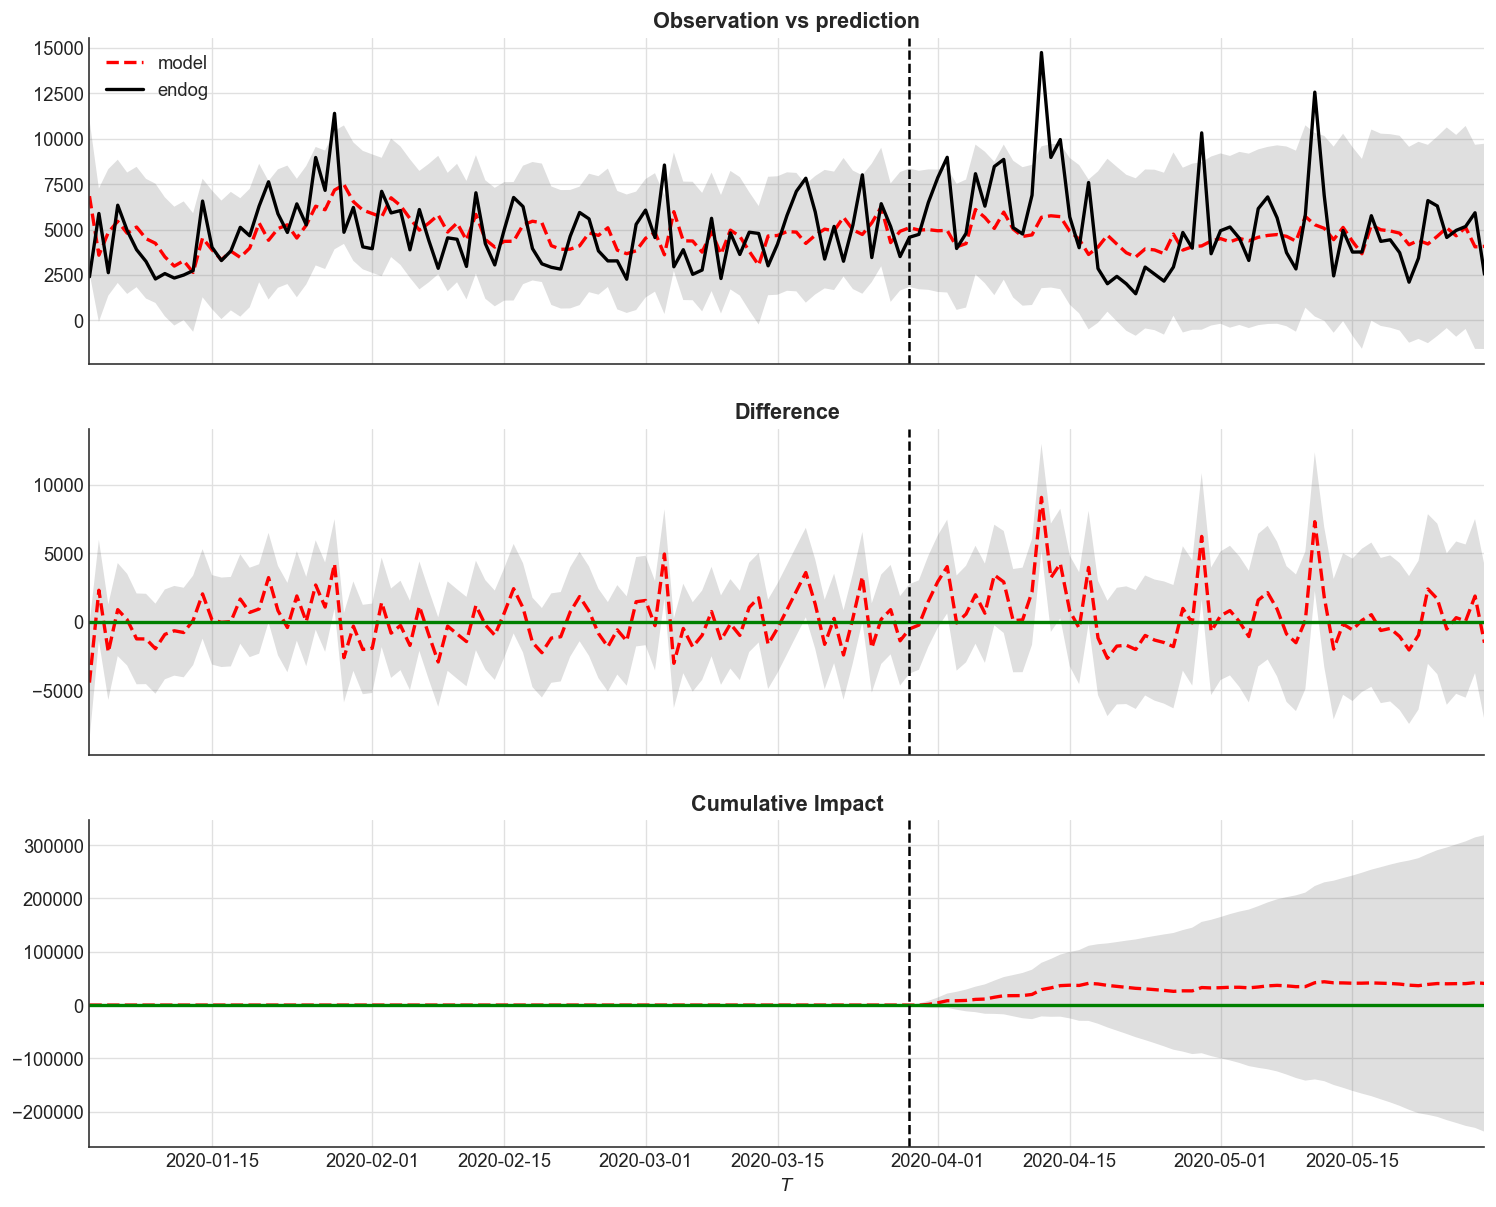

<Figure size 768x576 with 0 Axes>

In [24]:
# Рисуем и сохраняем график
bsts_inj.result.plot()
beautify_causalimpact_plot("Synthetic Intervention (+20% GMV) on Olist Data")
plt.show()